# Calidad de Datos y Modelos de Clasificación - Accidentes de Tránsito en Bucaramanga (Comuna Centro, 2017)

Queremos predecir si un accidente de tránsito en la Comuna Centro de Bucaramanga termina con víctimas (heridos o muertos) o solo con daños materiales. Los datos son los accidentes que publica la Secretaría de Tránsito de Bucaramanga en datos.gov.co (39.193 registros entre 2012 y 2023); nos quedamos con los de la Comuna Centro en 2017, que son 406.

1. Integración de los datos
2. Eliminar variables irrelevantes y redundantes
3. Descripción estadística de los datos
4. Limpieza de datos atípicos-errores
5. Limpieza de datos nulos: Imputación
6. Correlaciones para redundancias
7. Correlaciones para irrelevancia con la variable objetivo
8. Variable objetivo y balanceo
9. Selección de factores
10. Transformaciones (Dummies, LabelEncoder)
11. Validación cruzada (Árbol, Random Forest, XGBoost, KNN, Red Neuronal y SVM)
12. Comparación y selección del modelo
13. Hiperparametrización con GridSearchCV
14. Modelo final y guardado

* El despliegue con interfaz gráfica se realiza en otro jupyter notebook

In [20]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Integración de Datos

A diferencia del ejemplo de Empleados, aquí no hay que unir tablas con un `merge`: la base ya viene en un solo archivo de la Secretaría de Tránsito. Lo que sí revisamos es que el identificador (`ORDEN`) no se repita, porque si se repite hay accidentes duplicados.

El archivo trae el histórico de todo el municipio (todas las comunas, 2012-2023). Para trabajar con un conjunto más manejable y que cumpla el mínimo de 400 registros de la práctica, lo filtramos a la Comuna 15 - Centro y al año 2017.

In [21]:
# Se carga el archivo ORIGINAL COMPLETO tal como se descarga de datos.gov.co
data_completa = pd.read_csv("accidentes_bucaramanga_completo.csv", engine='python')
print("Registros y columnas del dataset original completo:", data_completa.shape)
data_completa.head()

Registros y columnas del dataset original completo: (39193, 24)


,ORDEN,FECHA,AÑO,MES,DÍA,GRAVEDAD,PEATON,AUTOMOVIL,CAMPERO,CAMIONETA,...,VOLQUETA,MOTO,BICICLETA,OTRO,BARRIO,HORA,ENTIDAD,COMUNA,Propietario de Vehículo,DIURNIO/NOCTURNO
0,1,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,0,1,0,0,...,0,0,0,0,Mutis,1899-12-31T12:15:00.000,AGENTES DTB,17. MUTIS,Particular,Diurno
1,2,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Regaderos Norte,1899-12-31T14:00:00.000,AGENTES DTB,02. NORORIENTAL,Empresa,Diurno
2,3,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,0,0,1,...,0,0,0,0,Cabecera Del Llano,1899-12-31T12:00:00.000,AGENTES DTB,12. CABECERA DEL LLANO,Particular,Diurno
3,4,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Norte Bajo,1899-12-31T18:30:00.000,AGENTES DTB,03. SAN FRANCISCO,Empresa,Nocturno
4,5,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,1,0,0,0,...,0,1,0,0,Dangond,1899-12-31T00:30:00.000,AGENTES DTB,11. SUR,Particular,Nocturno


In [22]:
# Exploramos las comunas y años disponibles para decidir el filtro
print(data_completa['COMUNA'].value_counts())
print()
print(data_completa['AÑO'].value_counts().sort_index())

COMUNA
12. CABECERA DEL LLANO    6415
03. SAN FRANCISCO         5287
13. ORIENTAL              5093
15. CENTRO                4405
06. LA CONCORDIA          3180
10. PROVENZA              2421
04. OCCIDENTAL            2143
NO DISPONIBLE             1553
05. GARCIA ROVIRA         1517
01. NORTE                 1209
09. LA PEDREGOSA          1188
07. LA CIUDADELA           861
16. LAGOS DEL CACIQUE      806
11. SUR                    716
17. MUTIS                  693
08. SUR OCCIDENTE          612
02. NORORIENTAL            535
14. MORRORICO              420
CORREG. 1                   83
CORREG. 3                   55
CORREG. 2                    1
Name: count, dtype: int64

AÑO
2012    4342
2013    4054
2014    3724
2015    3765
2016    3739
2017    3812
2018    3917
2019    3716
2020    2261
2021    2719
2022    2220
2023     924
Name: count, dtype: int64


In [23]:
# Filtramos a la Comuna 15 - Centro, año 2017
data = data_completa[(data_completa['COMUNA'] == '15. CENTRO') &
                      (data_completa['AÑO'] == 2017)].copy()

print("Registros y columnas después del filtro:", data.shape)
data.head()

Registros y columnas después del filtro: (406, 24)


,ORDEN,FECHA,AÑO,MES,DÍA,GRAVEDAD,PEATON,AUTOMOVIL,CAMPERO,CAMIONETA,...,VOLQUETA,MOTO,BICICLETA,OTRO,BARRIO,HORA,ENTIDAD,COMUNA,Propietario de Vehículo,DIURNIO/NOCTURNO
19647,19648,2017-01-04T00:00:00.000,2017,01. Enero,03. Miercoles,Solo daños,0,1,0,1,...,0,0,0,0,Garcia Rovira,1899-12-31T21:40:00.000,AGENTES DTB,15. CENTRO,Particular,Nocturno
19661,19662,2017-01-06T00:00:00.000,2017,01. Enero,05. Viernes,Con heridos,0,1,0,0,...,0,1,0,0,Centro,1899-12-31T12:45:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno
19668,19669,2017-01-08T00:00:00.000,2017,01. Enero,07. Domingo,Con heridos,0,1,0,0,...,0,1,0,0,Garcia Rovira,1899-12-31T19:20:00.000,AGENTES DTB,15. CENTRO,Empresa,Nocturno
19670,19671,2017-01-09T00:00:00.000,2017,01. Enero,01. Lunes,Solo daños,0,0,0,1,...,0,1,0,0,Centro,1899-12-31T14:30:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno
19678,19679,2017-01-10T00:00:00.000,2017,01. Enero,02. Martes,Solo daños,0,0,0,0,...,0,1,0,0,Centro,1899-12-31T13:15:00.000,AGENTES DTB,15. CENTRO,Empresa,Diurno


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406 entries, 19647 to 23430
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ORDEN                    406 non-null    int64 
 1   FECHA                    406 non-null    object
 2   AÑO                      406 non-null    int64 
 3   MES                      406 non-null    object
 4   DÍA                      406 non-null    object
 5   GRAVEDAD                 406 non-null    object
 6   PEATON                   406 non-null    int64 
 7   AUTOMOVIL                406 non-null    int64 
 8   CAMPERO                  406 non-null    int64 
 9   CAMIONETA                406 non-null    int64 
 10  MICRO                    406 non-null    int64 
 11  BUSETA                   406 non-null    int64 
 12  BUS                      406 non-null    int64 
 13  CAMION                   406 non-null    int64 
 14  VOLQUETA                 406 non-null    

In [25]:
#Revisamos si tenemos ID (ORDEN) repetidos
ids = data['ORDEN'].value_counts()
ids[ids > 1]

,count
ORDEN,


No hay identificadores repetidos, entonces no hay registros duplicados que eliminar. Pasamos de 39.193 registros a 406 (la Comuna Centro en 2017); las 24 columnas siguen iguales por ahora.

# 2. Eliminar variables irrelevantes y redundantes

Las irrelevantes son los identificadores, las columnas que siempre valen lo mismo y las que casi no varían. Las redundantes son las que repiten lo que ya dice otra columna. Como filtramos a una sola comuna y un solo año, `AÑO` y `COMUNA` quedaron constantes; la celda siguiente lo comprueba.

In [26]:
# Verificamos que AÑO y COMUNA quedaron constantes tras el filtro
print(data['AÑO'].unique())
print(data['COMUNA'].unique())
print(data['ENTIDAD'].unique())
print(data['VOLQUETA'].unique())

[2017]
['15. CENTRO']
['AGENTES DTB']
[0]


Irrelevantes:
- `ORDEN`: es solo el identificador de la fila.
- `AÑO` y `COMUNA`: después del filtro valen siempre 2017 y Centro.
- `ENTIDAD`: todos los registros los reportó AGENTES DTB.
- `VOLQUETA`: siempre es cero, ningún accidente de este grupo tuvo volquetas.
- `PEATON`, `CAMPERO`, `CAMIONETA`, `MICRO`, `BUSETA`, `BUS`, `CAMION`, `BICICLETA` y `OTRO`: columnas de conteo con pocos valores distintos de cero. `PEATON` y `CAMIONETA` son las más frecuentes (alrededor del 16 % de los accidentes) y las demás están por debajo del 9 %. Las dejamos por fuera para trabajar con las 8 variables predictoras del proyecto; es una limitación, porque `PEATON` y `CAMIONETA` sí podían haberse tenido en cuenta.

Redundantes:
- `FECHA`: ya está separada en `AÑO`, `MES` y `DÍA`.
- `HORA` en texto: la reemplazamos por la hora numérica (0 a 23) en la columna `Hora`.

Con esto quedan 9 columnas: las 8 predictoras y `Gravedad`. También pasamos `Mes`, `Dia`, `Jornada`, `Barrio` y `Propietario` a tipo categoría.

In [27]:
# Extraemos la hora como variable numérica (0-23) a partir del texto original de HORA
data['Hora'] = pd.to_datetime(data['HORA']).dt.hour

# Seleccionamos las 8 variables predictoras + la variable objetivo
columnas_finales = ['MES','DÍA','Hora','DIURNIO/NOCTURNO','BARRIO',
                     'Propietario de Vehículo','AUTOMOVIL','MOTO','GRAVEDAD']
data = data[columnas_finales].copy()
data.columns = ['Mes','Dia','Hora','Jornada','Barrio','Propietario','Automovil','Moto','Gravedad']
data.head()

,Mes,Dia,Hora,Jornada,Barrio,Propietario,Automovil,Moto,Gravedad
19647,01. Enero,03. Miercoles,21,Nocturno,Garcia Rovira,Particular,1,0,Solo daños
19661,01. Enero,05. Viernes,12,Diurno,Centro,Empresa,1,1,Con heridos
19668,01. Enero,07. Domingo,19,Nocturno,Garcia Rovira,Empresa,1,1,Con heridos
19670,01. Enero,01. Lunes,14,Diurno,Centro,Empresa,0,1,Solo daños
19678,01. Enero,02. Martes,13,Diurno,Centro,Empresa,0,1,Solo daños


In [28]:
#Corrección del tipo de datos object a categorías
data['Mes']=data['Mes'].astype('category')
data['Dia']=data['Dia'].astype('category')
data['Jornada']=data['Jornada'].astype('category')
data['Barrio']=data['Barrio'].astype('category')
data['Propietario']=data['Propietario'].astype('category')
data['Gravedad']=data['Gravedad'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406 entries, 19647 to 23430
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Mes          406 non-null    category
 1   Dia          406 non-null    category
 2   Hora         406 non-null    int32   
 3   Jornada      406 non-null    category
 4   Barrio       406 non-null    category
 5   Propietario  406 non-null    category
 6   Automovil    406 non-null    int64   
 7   Moto         406 non-null    int64   
 8   Gravedad     406 non-null    category
dtypes: category(6), int32(1), int64(2)
memory usage: 14.7 KB


# 3. Descripción estadística

Variable objetivo: `Gravedad` (Solo daños / Con heridos / Con muertos)

Variables predictoras (8): `Mes`, `Dia`, `Hora`, `Jornada`, `Barrio`, `Propietario`, `Automovil`, `Moto`

Primero miramos las numéricas con `describe`, histogramas y boxplots, y después las categóricas con gráficos de barras.

**Variables numéricas**

In [29]:
#Conocemos un poco los datos numéricos
data.describe()

,Hora,Automovil,Moto
count,406.000000,406.000000,406.000000
mean,13.256158,0.748768,0.655172
std,4.911905,0.674719,0.639684
min,0.000000,0.000000,0.000000
25%,9.250000,0.000000,0.000000
50%,13.000000,1.000000,1.000000
75%,17.000000,1.000000,1.000000
max,23.000000,3.000000,3.000000


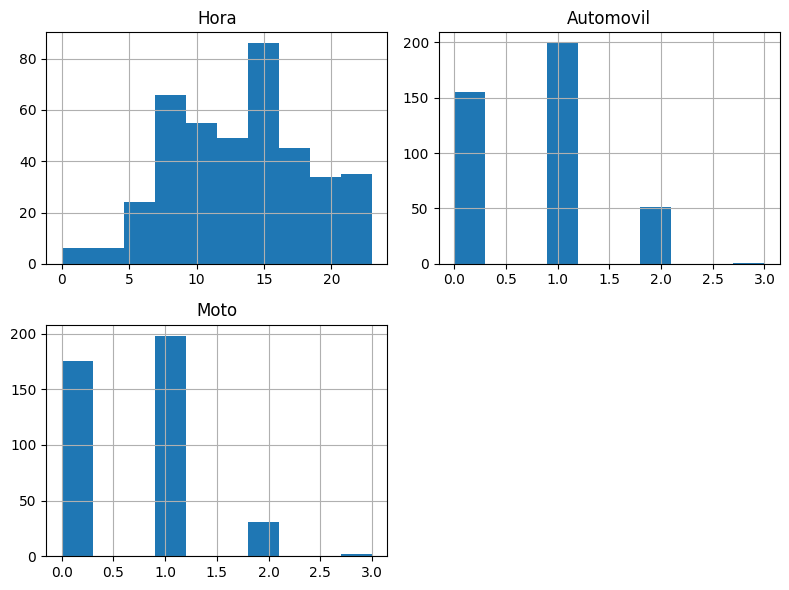

In [30]:
#histograma
data.hist(figsize=(8,6))
plt.tight_layout()

<Axes: >

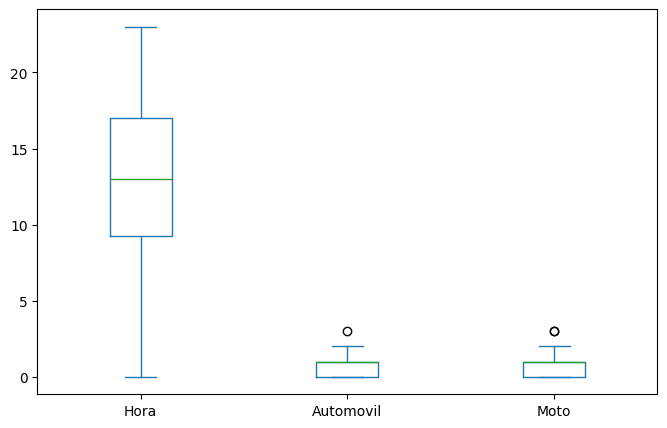

In [31]:
#Boxplot
data.plot.box(figsize=(8,5))

<Axes: >

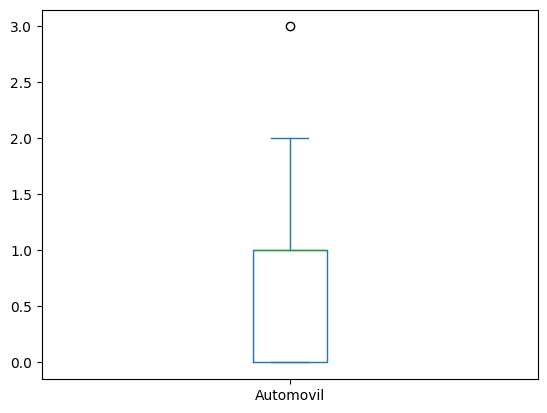

In [32]:
#Boxplot para una sola variable
data['Automovil'].plot.box()

<Axes: >

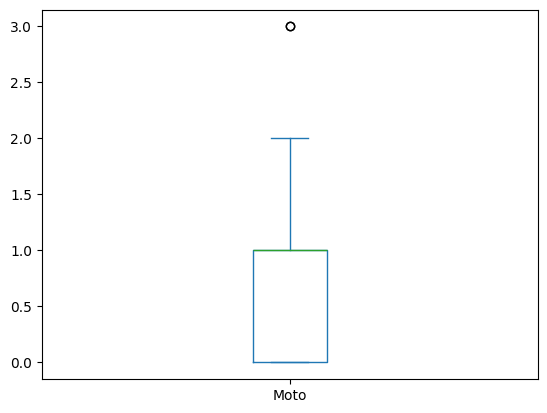

In [33]:
#Boxplot para una sola variable
data['Moto'].plot.box()

<Axes: >

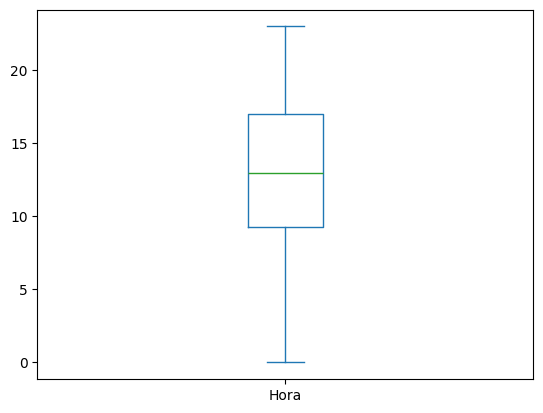

In [34]:
#Boxplot para una sola variable
data['Hora'].plot.box()

`Hora` va de 0 a 23, con media de 13.3 y mediana de 13; la mitad de los accidentes pasa entre las 9:15 y las 17:00. `Automovil` y `Moto` son conteos pequeños: en 155 accidentes no hubo automóviles, en 199 hubo uno, en 51 dos y en 1 tres; con las motos, 175 accidentes no tuvieron ninguna, 198 tuvieron una, 31 dos y 2 tres. El boxplot marca como atípicos los de 2 o 3 vehículos, pero son casos que sí pueden pasar (lo vemos en la sección 4).

**Variables categóricas** (value_counts())

<Axes: xlabel='Gravedad'>

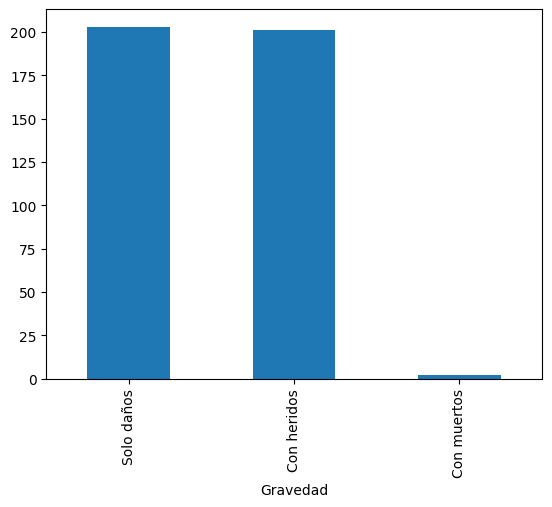

In [35]:
#Conocemos las variables categóricas: bar, barh, pie
data['Gravedad'].value_counts().plot(kind='bar')

<Axes: xlabel='Jornada'>

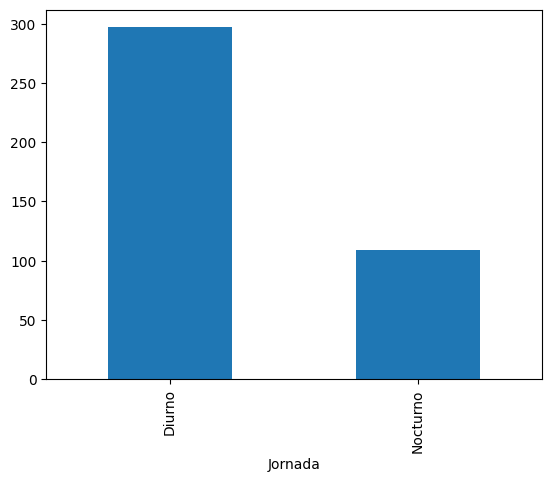

In [36]:
data['Jornada'].value_counts().plot(kind='bar')

<Axes: xlabel='Propietario'>

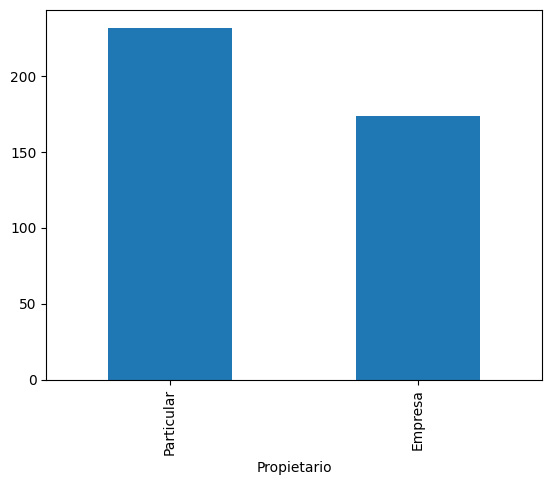

In [37]:
data['Propietario'].value_counts().plot(kind='bar')

<Axes: xlabel='Barrio'>

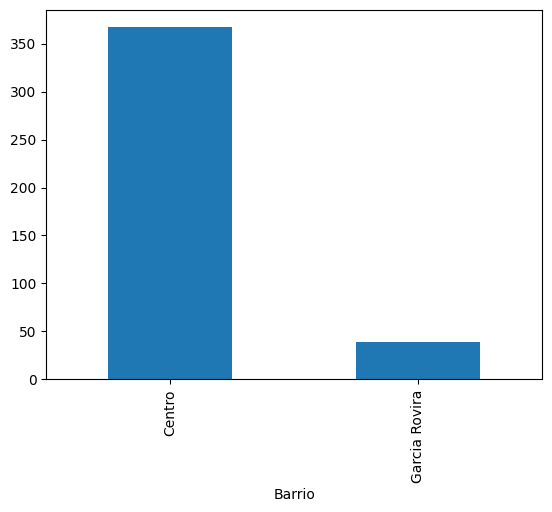

In [38]:
data['Barrio'].value_counts().plot(kind='bar')

`Gravedad` está casi balanceada entre `Solo daños` (203) y `Con heridos` (201), y solo hay 2 accidentes con muertos (lo resolvemos en la sección 8). De día pasan 297 accidentes (73 %) y de noche 109 (27 %). Con vehículos particulares hay 232 (57 %) y de empresa 174 (43 %). En `Barrio`, 367 accidentes (90 %) son en el Centro y solo 39 (10 %) en García Rovira; como casi todo está en un solo barrio, esta variable tiene poco para diferenciar.

array([[<Axes: xlabel='Hora', ylabel='Hora'>,
        <Axes: xlabel='Automovil', ylabel='Hora'>,
        <Axes: xlabel='Moto', ylabel='Hora'>],
       [<Axes: xlabel='Hora', ylabel='Automovil'>,
        <Axes: xlabel='Automovil', ylabel='Automovil'>,
        <Axes: xlabel='Moto', ylabel='Automovil'>],
       [<Axes: xlabel='Hora', ylabel='Moto'>,
        <Axes: xlabel='Automovil', ylabel='Moto'>,
        <Axes: xlabel='Moto', ylabel='Moto'>]], dtype=object)

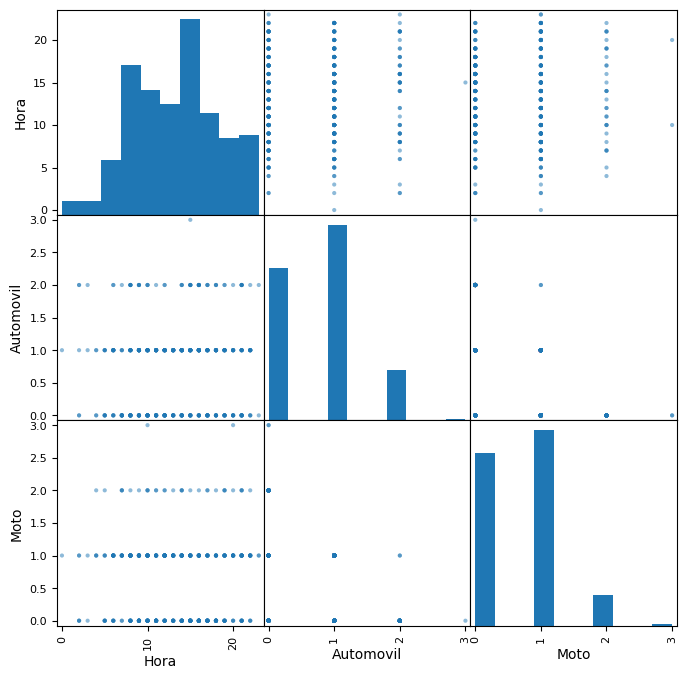

In [39]:
# Gráficas para identificar relaciones entre las variables numéricas
pd.plotting.scatter_matrix(data[['Hora','Automovil','Moto']], figsize=(8,8))

Como `Automovil` y `Moto` toman pocos valores enteros, los puntos se montan unos sobre otros y casi no se ve nada. Es más útil la correlación numérica de la sección 6: `Automovil` y `Moto` están relacionadas negativamente (-0.45) y `Hora` no se relaciona con ninguna de las dos.

**Perfilado de datos**

In [40]:
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00


In [41]:
from ydata_profiling import ProfileReport

profile_data = ProfileReport(data, minimal=True) # minimal=True
profile_data

/tmp/ipykernel_652/253920178.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 113.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:** ¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados?

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

# **Diagnóstico de las dimensiones según el perfilado:**
* **Completitud:** 100% completo, no existen valores nulos en ninguna de las 9 columnas (verificado en la sección 5).
* **Exactitud:** no se encontraron errores lógicos (horas fuera de 0-23, conteos de vehículos negativos, ni filas con cero vehículos/peatones involucrados). Ver detalle en la sección 4.
* **Conformidad:** las categorías de `Mes` y `Dia` vienen prefijadas con un número (ej. "01. Enero"), lo que garantiza un orden correcto pero no es el formato típico de texto; se documenta pero no se considera un error.
* **Oportunidad:** no se puede verificar con los metadatos disponibles del portal.
* **Duplicidad:** no se encontraron identificadores (`ORDEN`) repetidos.
* **Integridad:** el subconjunto queda limitado a una sola comuna y año (por diseño, para reducir el tamaño del archivo), por lo que no es representativo del municipio completo; esto se documenta como limitación del alcance, no como un problema de integridad interna de los datos.

# 4. Limpieza de datos atípicos-errores
- Sólo se limpian errores (valores lógicamente imposibles), no cualquier valor estadísticamente atípico.

Un error sería, por ejemplo, una hora 25 o un conteo de vehículos negativo; un atípico es un valor raro pero posible, como un choque con 3 motos. Revisamos que `Hora` esté entre 0 y 23 y que `Automovil` y `Moto` no sean negativos.

In [43]:
data.describe()

,Hora,Automovil,Moto
count,406.000000,406.000000,406.000000
mean,13.256158,0.748768,0.655172
std,4.911905,0.674719,0.639684
min,0.000000,0.000000,0.000000
25%,9.250000,0.000000,0.000000
50%,13.000000,1.000000,1.000000
75%,17.000000,1.000000,1.000000
max,23.000000,3.000000,3.000000


In [44]:
# Revisión de errores lógicos:
# - Hora debe estar entre 0 y 23
# - Automovil y Moto (conteo de vehículos involucrados) no pueden ser negativos
print("Horas fuera de 0-23:", ((data['Hora']<0) | (data['Hora']>23)).sum())
print("Automovil negativos:", (data['Automovil']<0).sum())
print("Moto negativos:", (data['Moto']<0).sum())

Horas fuera de 0-23: 0
Automovil negativos: 0
Moto negativos: 0


No hay errores lógicos (0 horas fuera de rango y 0 conteos negativos). Los accidentes con 2 o 3 vehículos que marca el boxplot pueden pasar en choques múltiples, así que no los eliminamos ni los pasamos a nulo. Los 406 registros se quedan.

# 5. Limpieza de datos nulos: Imputación

Estrategia:
* Eliminar registros con más de 15% de nulos
* Eliminar columnas con más de 15%-20% de nulos
* Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
* Para casos especiales se crea modelo predictivo

In [45]:
# Porcentaje de nulos por columna
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

,0
Mes,0.0
Dia,0.0
Hora,0.0
Jornada,0.0
Barrio,0.0
Propietario,0.0
Automovil,0.0
Moto,0.0
Gravedad,0.0


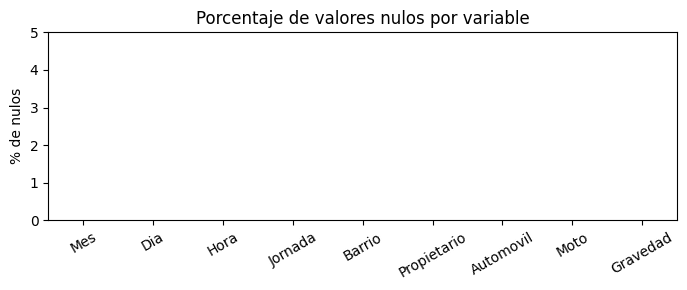

In [46]:
# Porcentaje de nulos de manera grafica
import matplotlib.pyplot as plt

nulos_pct = (data.isna().sum() / len(data) * 100)
nulos_pct.plot(kind='bar', color='#8172B2', figsize=(7,3))
plt.ylabel('% de nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.ylim(0,5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

No hay nulos en ninguna de las 9 columnas, así que no hace falta imputar. Dejamos el código de `SimpleImputer` como referencia por si más adelante se juntan más comunas o años.

In [47]:
from sklearn.impute import SimpleImputer

# Código de referencia (no se ejecuta imputación real porque no hay nulos):
# ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
# data[['Hora','Automovil','Moto']] = ImpNumeros.fit_transform(data[['Hora','Automovil','Moto']])
print("No hay nulos que imputar: 0 valores faltantes en", data.shape[0], "registros y", data.shape[1], "columnas.")

No hay nulos que imputar: 0 valores faltantes en 406 registros y 9 columnas.


# 6. Correlaciones para redundancias

Para calcular correlaciones todo tiene que ser numérico, así que primero creamos dummies de las variables categóricas. Buscamos pares de predictoras con correlación mayor a |0.8|: si dos variables dicen casi lo mismo, nos quedamos con una.

In [48]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas
data_num = pd.get_dummies(data, drop_first=True, dtype=int)
data_num.head()

,Hora,Automovil,Moto,Mes_02. Febrero,Mes_03. Marzo,Mes_04. Abril,Mes_05. Mayo,Mes_06. Junio,Mes_07. Julio,Mes_08. Agosto,...,Dia_03. Miercoles,Dia_04. Jueves,Dia_05. Viernes,Dia_06. Sabado,Dia_07. Domingo,Jornada_Nocturno,Barrio_Garcia Rovira,Propietario_Particular,Gravedad_Con muertos,Gravedad_Solo daños
19647,21,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,1,0,1
19661,12,1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
19668,19,1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,0,0
19670,14,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19678,13,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Correlaciones para redundancia = mayores |0.8|. En el mapa de calor buscamos colores muy fuertes fuera de la diagonal entre predictoras.

In [49]:
#Correlaciones
correlaciones = data_num.corr()
correlaciones

,Hora,Automovil,Moto,Mes_02. Febrero,Mes_03. Marzo,Mes_04. Abril,Mes_05. Mayo,Mes_06. Junio,Mes_07. Julio,Mes_08. Agosto,...,Dia_03. Miercoles,Dia_04. Jueves,Dia_05. Viernes,Dia_06. Sabado,Dia_07. Domingo,Jornada_Nocturno,Barrio_Garcia Rovira,Propietario_Particular,Gravedad_Con muertos,Gravedad_Solo daños
Hora,1.000000,0.048522,-8.942224e-04,0.023855,-0.070649,3.425492e-02,-0.007154,-0.041081,0.066710,-0.020023,...,-0.061084,-2.962180e-02,0.038810,0.073955,0.006502,0.422663,0.076688,-0.017682,-0.139923,-5.823948e-02
Automovil,0.048522,1.000000,-4.529296e-01,0.054792,0.003887,-2.432911e-02,-0.060717,0.036373,0.027663,0.054553,...,-0.011495,5.372841e-02,0.074927,-0.035666,-0.037973,0.019664,-0.176155,-0.116062,-0.025974,4.312893e-01
Moto,-0.000894,-0.452930,1.000000e+00,-0.042429,-0.008757,1.496926e-02,0.036132,-0.026524,-0.013814,-0.043420,...,-0.123553,4.818969e-02,-0.063610,0.079991,0.073008,0.048595,0.162860,0.124644,0.037975,-5.011728e-01
Mes_02. Febrero,0.023855,0.054792,-4.242871e-02,1.000000,-0.087005,-8.112739e-02,-0.096700,-0.089843,-0.085561,-0.092625,...,0.042336,4.204816e-02,0.068557,-0.035008,-0.070970,0.070313,-0.064333,-0.079163,-0.020581,1.828181e-02
Mes_03. Marzo,-0.070649,0.003887,-8.756554e-03,-0.087005,1.000000,-8.249562e-02,-0.098331,-0.091359,-0.087005,-0.094187,...,0.037738,3.785628e-02,0.037856,0.009398,-0.102373,-0.139515,-0.005198,-0.088466,-0.020928,9.914739e-02
Mes_04. Abril,0.034255,-0.024329,1.496926e-02,-0.081127,-0.082496,1.000000e+00,-0.091689,-0.085187,-0.081127,-0.087825,...,-0.046008,1.173947e-17,0.027735,-0.023645,0.059938,0.047786,0.006955,-0.011043,-0.019514,9.563796e-03
Mes_05. Mayo,-0.007154,-0.060717,3.613155e-02,-0.096700,-0.098331,-9.168911e-02,1.000000,-0.101540,-0.096700,-0.104683,...,-0.013381,-3.636488e-02,-0.036365,-0.039565,0.020507,-0.069728,0.032468,0.186094,0.212831,-3.305898e-02
Mes_06. Junio,-0.041081,0.036373,-2.652401e-02,-0.089843,-0.091359,-8.518741e-02,-0.101540,1.000000,-0.089843,-0.097260,...,0.005299,4.387822e-03,0.004388,-0.045521,-0.020159,-0.027655,0.048779,0.088666,-0.021611,-8.775645e-03
Mes_07. Julio,0.066710,0.027663,-1.381400e-02,-0.085561,-0.087005,-8.112739e-02,-0.096700,-0.089843,1.000000,-0.092625,...,0.017711,-9.049496e-02,-0.010969,-0.010670,-0.041265,0.049686,0.090770,0.105550,-0.020581,-3.656362e-02
Mes_08. Agosto,-0.020023,0.054553,-4.341961e-02,-0.092625,-0.094187,-8.782456e-02,-0.104683,-0.097260,-0.092625,1.000000,...,0.020614,-5.220544e-02,-0.027386,0.039006,-0.053362,-0.037339,-0.074182,-0.192704,-0.022280,8.558269e-03


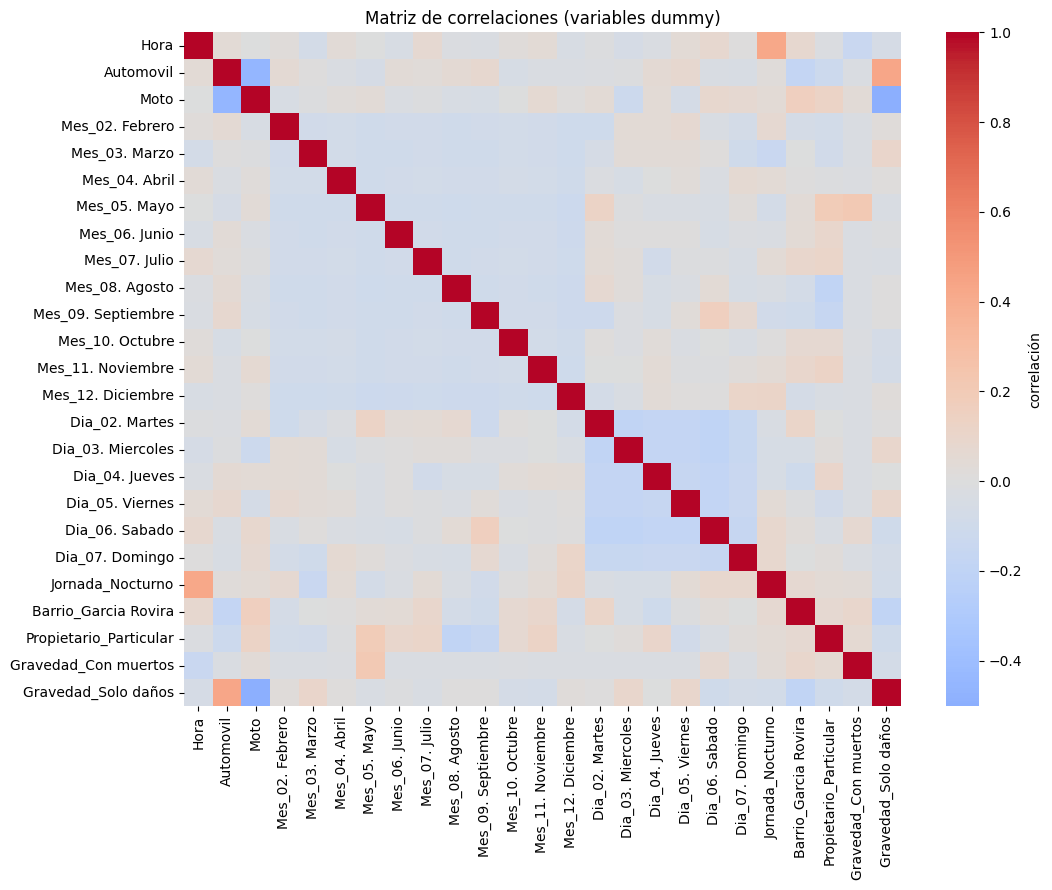

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(correlaciones, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label':'correlación'})
plt.title('Matriz de correlaciones (variables dummy)')
plt.tight_layout()
plt.show()

In [51]:
# Búsqueda automática de pares de variables PREDICTORAS con correlación > 0.8 en valor absoluto
target_cols = [c for c in correlaciones.columns if c.startswith('Gravedad_')]
pred_cols = [c for c in correlaciones.columns if c not in target_cols]

pares_redundantes = []
for i, c1 in enumerate(pred_cols):
    for c2 in pred_cols[i+1:]:
        v = correlaciones.loc[c1, c2]
        if abs(v) > 0.8:
            pares_redundantes.append((c1, c2, round(v,3)))

print("Pares de variables predictoras con |correlación| > 0.8:", pares_redundantes)

Pares de variables predictoras con |correlación| > 0.8: []


No hay pares de predictoras con correlación mayor a |0.8|, entonces no hay redundancia y no eliminamos nada. Las correlaciones más altas son `Automovil` con `Moto` (-0.45) y `Hora` con `Jornada_Nocturno` (0.42); tienen sentido, pero no son tan altas como para ser la misma información.

# 7. Correlaciones para irrelevancia con la variable objetivo

Aquí buscamos variables con correlación muy baja con la variable objetivo (0.0 a 0.05); serían candidatas a eliminarse, pero la decisión final la tomamos en la sección 9.

`Gravedad` tiene 3 categorías, así que `get_dummies` crea `Gravedad_Con muertos` y `Gravedad_Solo daños` (con "Con heridos" como base). Como "Con muertos" solo tiene 2 registros, su correlación no es confiable y usamos `Gravedad_Solo daños`, que compara los accidentes sin víctimas contra los que tuvieron heridos o muertos. Una correlación negativa significa que, al subir la variable, hay más accidentes con víctimas.

In [52]:
#Correlaciones con la variable objetivo (accidentes con víctimas vs. solo daños)
cor_variable_obj = correlaciones.loc['Gravedad_Solo daños'].drop(target_cols)
cor_variable_obj.sort_values(key=abs, ascending=False)

,Gravedad_Solo daños
Moto,-5.011728e-01
Automovil,4.312893e-01
Barrio_Garcia Rovira,-1.922483e-01
Propietario_Particular,-9.954315e-02
Mes_03. Marzo,9.914739e-02
Dia_06. Sabado,-9.836753e-02
Dia_03. Miercoles,8.625933e-02
Dia_05. Viernes,8.571429e-02
Jornada_Nocturno,-8.336808e-02
Mes_11. Noviembre,-7.312724e-02


Text(0.5, 1.0, 'Correlación de cada predictora con Gravedad_Solo daños')

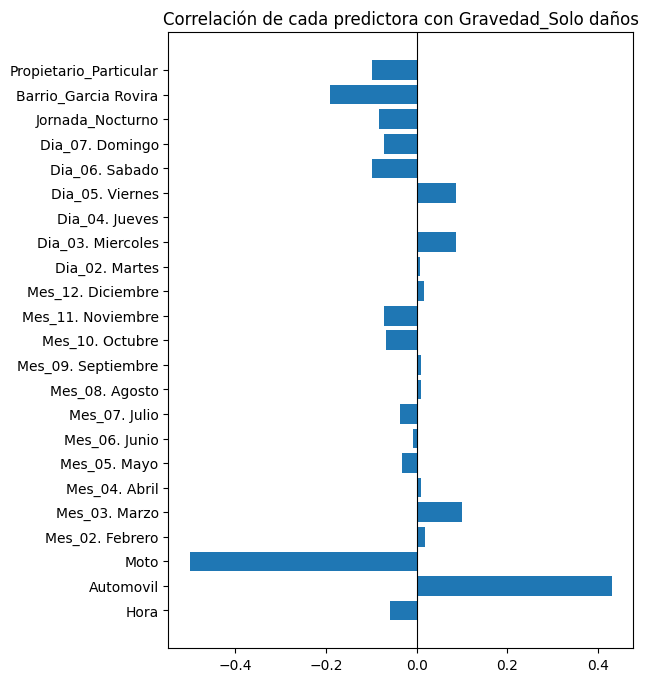

In [53]:
plt.figure(figsize=(6, 8))
plt.barh(y=cor_variable_obj.index, width=cor_variable_obj.values)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada predictora con Gravedad_Solo daños')

`Moto` (-0.50) y `Automovil` (0.43) son las más correlacionadas con la gravedad, y después viene `Barrio_Garcia Rovira` (-0.19). `Hora`, `Jornada`, `Propietario` y casi todas las dummies de mes y día quedan alrededor de |0.10| o menos. Las dummies de `Mes` y `Dia` salen débiles casi por construcción, porque cada una describe un solo mes o un solo día; por eso no eliminamos nada solo con este criterio y lo decidimos en la sección 9.

# 8. Variable objetivo y balanceo

`Gravedad` tiene solo 2 accidentes con muertos. Con tan pocos casos no se puede validar un modelo: en una validación cruzada de 10 pliegues esa clase ni siquiera aparece en todos, y si se aumenta con SMOTE a partir de 2 registros solo se copian esos mismos casos (en una versión anterior el modelo parecía acertar casi todos los de esa clase, pero era porque veía copias de lo mismo). Por eso juntamos `Con heridos` y `Con muertos` en una sola clase, `Con víctimas`, y dejamos `Solo daños`. Quedan 203 accidentes de cada clase, así que ya no hace falta balancear ni usar SMOTE.

Gravedad
Solo daños      203
Con víctimas    203
Name: count, dtype: int64


<Axes: xlabel='Gravedad'>

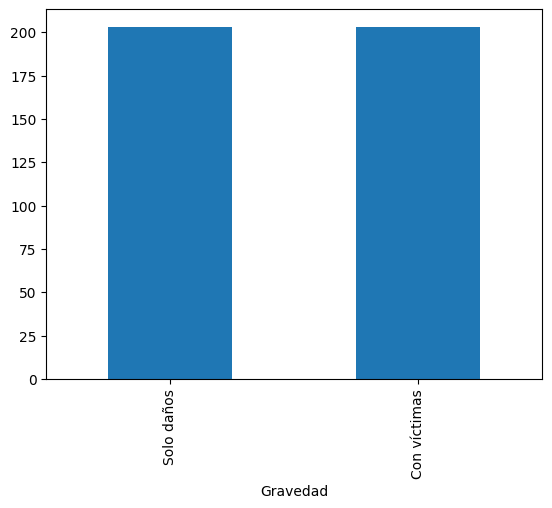

In [54]:
#La clase "Con muertos" solo tiene 2 registros, se junta con "Con heridos"
data['Gravedad'] = data['Gravedad'].astype(str).replace({'Con heridos':'Con víctimas', 'Con muertos':'Con víctimas'})

print(data['Gravedad'].value_counts())
data['Gravedad'].value_counts().plot(kind='bar')

Si la clase minoritaria fuera menos del 40 % se usaría SMOTE o `class_weight='balanced'`, pero aquí las dos clases están en 50 % y 50 %.

# 9. Selección de factores

Queremos quedarnos con las variables que sí tienen relación con la gravedad del accidente. Para las 8 candidatas (`Mes`, `Dia`, `Hora`, `Jornada`, `Barrio`, `Propietario`, `Automovil`, `Moto`) miramos tres cosas:

1. Una prueba estadística de asociación con la gravedad (Chi-cuadrado para las categóricas y Mann-Whitney para las numéricas). Si el p-valor es menor a 0.05, la relación es significativa y la variable se queda.
2. La información mutua, que mide cuánta información da la variable sobre la gravedad (0 significa que no tiene relación).
3. La importancia de la variable en un Random Forest.

La redundancia ya la revisamos en la sección 6 y no había. En la tabla, la columna `Seleccionada` es True cuando el p-valor es menor a 0.05.

In [55]:
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

objetivo = 'Gravedad'
numericas = ['Hora', 'Automovil', 'Moto']
predictoras = [c for c in data.columns if c != objetivo]
categoricas = [c for c in predictoras if c not in numericas]
y_bin = (data[objetivo] == 'Con víctimas').astype(int)

# --- Criterio 1: prueba de asociación con la variable objetivo
filas = []
for c in predictoras:
    if c in numericas:
        p = mannwhitneyu(data.loc[y_bin == 1, c], data.loc[y_bin == 0, c], alternative='two-sided').pvalue
        prueba = 'Mann-Whitney U'
    else:
        p = chi2_contingency(pd.crosstab(data[c].astype(str), y_bin))[1]
        prueba = 'Chi-cuadrado'
    filas.append({'Variable': c, 'Prueba': prueba, 'p-valor': p})
seleccion = pd.DataFrame(filas).set_index('Variable')

# --- Criterio 2: información mutua (variables codificadas como enteros)
X_cod = data[predictoras].copy()
for c in categoricas:
    X_cod[c] = X_cod[c].astype(str).astype('category').cat.codes
seleccion['Info. mutua'] = mutual_info_classif(X_cod, y_bin, discrete_features=True, random_state=42)

# --- Criterio 3: importancia Random Forest (dummies sumadas por variable original)
X_dum = pd.get_dummies(data[predictoras].astype({c: str for c in categoricas}), columns=categoricas, dtype=int)
rf_sel = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42).fit(X_dum, y_bin)
imp = pd.Series(rf_sel.feature_importances_, index=X_dum.columns)
origen = lambda col: next(v for v in predictoras if col == v or col.startswith(v + '_'))
seleccion['Importancia RF'] = imp.groupby(origen).sum()

seleccion['Seleccionada'] = seleccion['p-valor'] < 0.05
seleccion = seleccion.sort_values('p-valor')
seleccion.round(4)

,Prueba,p-valor,Info. mutua,Importancia RF,Seleccionada
Variable,,,,,
Moto,Mann-Whitney U,0.0000,0.1515,0.3706,True
Automovil,Mann-Whitney U,0.0000,0.1035,0.2166,True
Barrio,Chi-cuadrado,0.0002,0.0196,0.0497,True
Propietario,Chi-cuadrado,0.0567,0.0050,0.0361,False
Dia,Chi-cuadrado,0.1113,0.0128,0.0902,False
Jornada,Chi-cuadrado,0.1169,0.0035,0.0222,False
Hora,Mann-Whitney U,0.2639,0.0428,0.1145,False
Mes,Chi-cuadrado,0.5329,0.0124,0.1001,False


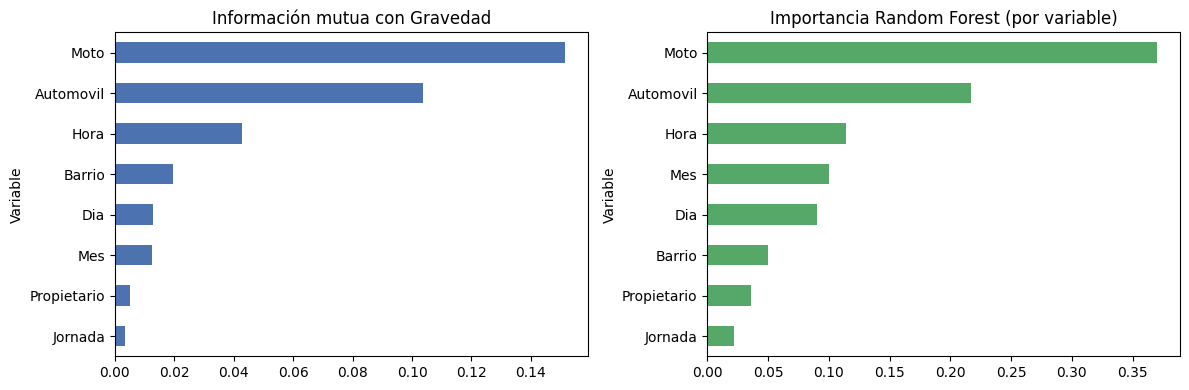

In [56]:
# Evidencia gráfica: información mutua e importancia RF por variable
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
seleccion['Info. mutua'].sort_values().plot.barh(ax=ax[0], color='#4C72B0', title='Información mutua con Gravedad')
seleccion['Importancia RF'].sort_values().plot.barh(ax=ax[1], color='#55A868', title='Importancia Random Forest (por variable)')
plt.tight_layout()
plt.show()

In [57]:
variables_seleccionadas = seleccion.index[seleccion['Seleccionada']].tolist()

# Respaldo: si el criterio estadístico deja menos de 3 variables, se toman las 3 con mayor información mutua
if len(variables_seleccionadas) < 3:
    variables_seleccionadas = seleccion['Info. mutua'].nlargest(3).index.tolist()

descartadas = [c for c in predictoras if c not in variables_seleccionadas]
print("Variables seleccionadas:", variables_seleccionadas)
print("Variables descartadas:  ", descartadas)

Variables seleccionadas: ['Moto', 'Automovil', 'Barrio']
Variables descartadas:   ['Mes', 'Dia', 'Hora', 'Jornada', 'Propietario']


De las 8 variables se quedaron 3: `Moto`, `Automovil` y `Barrio` (Centro / García Rovira), que son las únicas con p-valor menor a 0.05 (`Moto` y `Automovil` menores a 0.001 y `Barrio` 0.0002). `Moto` también es la más importante en información mutua (0.152) y en el Random Forest (0.371), seguida de `Automovil` (0.104 y 0.217). Por las correlaciones de la sección 7, más motos se asocia con accidentes con víctimas y más automóviles con accidentes de solo daños.

Descartamos `Mes`, `Dia`, `Hora`, `Jornada` y `Propietario`. `Hora` (p = 0.26) y `Mes` (p = 0.53) no muestran relación; `Propietario` (p = 0.057), `Dia` (p = 0.11) y `Jornada` (p = 0.12) quedaron cerca del umbral, pero con 406 registros no se distinguen del azar.

Una limitación: la selección la hicimos con todos los registros y lo ideal sería repetirla dentro de cada pliegue de la validación cruzada. Con solo 8 candidatas el efecto es pequeño.

# 10. Transformaciones

Dejamos solo las variables seleccionadas: `Moto` y `Automovil` (numéricas) y `Barrio` (categórica de 2 categorías). `Barrio` se convierte en una dummy (`Barrio_Garcia Rovira`) y la variable objetivo se codifica con LabelEncoder (`Con víctimas` = 0 y `Solo daños` = 1). La normalización de las numéricas la hacemos más adelante, solo para los modelos que la necesitan (KNN, red neuronal y SVM).

In [58]:
#Configuración de variables (las que quedaron en la selección de factores)
objetivo='Gravedad'
predictoras_numericas=['Moto','Automovil']
predictoras_categoricas_2cat=['Barrio']

data = data[predictoras_numericas + predictoras_categoricas_2cat + [objetivo]]
data.head()

,Moto,Automovil,Barrio,Gravedad
19647,0,1,Garcia Rovira,Solo daños
19661,1,1,Centro,Con víctimas
19668,1,1,Garcia Rovira,Con víctimas
19670,1,0,Centro,Solo daños
19678,1,0,Centro,Solo daños


In [59]:
#Información que necesita el despliegue (rangos de las numéricas y categorías)
info_despliegue = {
    'objetivo': objetivo,
    'columnas_entrada': predictoras_numericas + predictoras_categoricas_2cat,
    'numericas': {c: [int(data[c].min()), int(data[c].max())] for c in predictoras_numericas},
    'categoricas': {c: sorted(data[c].astype(str).unique().tolist()) for c in predictoras_categoricas_2cat},
}
info_despliegue

{'objetivo': 'Gravedad',
 'columnas_entrada': ['Moto', 'Automovil', 'Barrio'],
 'numericas': {'Moto': [0, 3], 'Automovil': [0, 3]},
 'categoricas': {'Barrio': ['Centro', 'Garcia Rovira']}}

In [60]:
#Dummies para las variables predictoras
data = pd.get_dummies(data, columns=predictoras_categoricas_2cat, drop_first=True, dtype=int) #2 categorías

data.head()

,Moto,Automovil,Gravedad,Barrio_Garcia Rovira
19647,0,1,Solo daños,1
19661,1,1,Con víctimas,0
19668,1,1,Con víctimas,1
19670,1,0,Solo daños,0
19678,1,0,Solo daños,0


In [61]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(data[objetivo])

print(labelencoder.classes_) #0 = Con víctimas, 1 = Solo daños
data.head()

['Con víctimas' 'Solo daños']


,Moto,Automovil,Gravedad,Barrio_Garcia Rovira
19647,0,1,1,1
19661,1,1,0,0
19668,1,1,0,1
19670,1,0,1,0
19678,1,0,1,0


# 11. Validación cruzada

El objetivo del modelo es predecir si un accidente de tránsito en la Comuna Centro de Bucaramanga termina con víctimas o solo con daños materiales, a partir de cuántas motos y automóviles intervienen y del barrio. Sirve para entender qué condiciones se asocian con accidentes más graves.

Para evaluar usamos validación cruzada estratificada de 10 pliegues (cada pliegue conserva la proporción de las dos clases) y miramos el F1 macro, que promedia el F1 de las dos clases; también sacamos exactitud, precisión y recall. Con `return_train_score=True` comparamos train contra test: si la diferencia pasa de 5 puntos hay overfitting, y si el F1 es bajo hasta en train puede ser underfitting.

Primero probamos Tree, Random Forest y XGBoost, que no necesitan normalizar. Después normalizamos las variables numéricas y probamos KNN, red neuronal y SVM.

In [62]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

#Dataframes para comparar los modelos
comparacion_CV=pd.DataFrame()      #f1 de test en cada pliegue
comparacion_train=pd.DataFrame()   #f1 de train en cada pliegue
scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #Muestreo estratificado

#Para que no salgan los avisos de convergencia de la red neuronal
import warnings
warnings.filterwarnings('ignore')

In [63]:
#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406 entries, 19647 to 23430
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Moto                  406 non-null    int64
 1   Automovil             406 non-null    int64
 2   Barrio_Garcia Rovira  406 non-null    int64
dtypes: int64(3)
memory usage: 12.7 KB


# TREE

Árbol de decisión con criterio gini, mínimo 10 registros por hoja y máximo 5 niveles de profundidad, para que no memorice los datos.

In [64]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=10, max_depth=5, random_state=42)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.005678,0.016163,0.707143,0.752068,0.707317,0.753425,0.709330,0.758680,0.708333,0.753228
1,0.011960,0.030079,0.729129,0.748754,0.731707,0.750685,0.736520,0.758139,0.729762,0.750450
2,0.003689,0.015179,0.778378,0.742975,0.780488,0.745205,0.797500,0.753496,0.783333,0.744956
3,0.012867,0.017009,0.849265,0.736113,0.853659,0.736986,0.888889,0.740485,0.850000,0.737149
4,0.007555,0.022944,0.653382,0.756917,0.658537,0.758904,0.663750,0.768192,0.655952,0.759158
5,0.008117,0.029570,0.778378,0.744099,0.780488,0.745205,0.786765,0.749893,0.778571,0.745391
6,0.007493,0.027618,0.696970,0.753036,0.700000,0.754098,0.708333,0.758545,0.700000,0.754098
7,0.008781,0.025180,0.874293,0.733730,0.875000,0.734973,0.883632,0.739441,0.875000,0.734973
8,0.013865,0.053698,0.724828,0.750006,0.725000,0.751366,0.725564,0.756960,0.725000,0.751366
9,0.002813,0.008630,0.673162,0.755691,0.675000,0.756831,0.679028,0.761715,0.675000,0.756831


In [65]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.008282
score_time,0.024607
test_f1_macro,0.746493
train_f1_macro,0.747339
test_accuracy,0.748720
train_accuracy,0.748768
test_precision_macro,0.757931
train_precision_macro,0.754555
test_recall_macro,0.748095
train_recall_macro,0.748760


In [66]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_f1_macro']
comparacion_train['Tree']=scores['train_f1_macro']
comparacion_CV

,Tree
0,0.707143
1,0.729129
2,0.778378
3,0.849265
4,0.653382
5,0.778378
6,0.696970
7,0.874293
8,0.724828
9,0.673162


El árbol da un F1 de 0.746 en test y 0.747 en train. Casi no hay diferencia, así que no hay overfitting.

# RANDOM FOREST

Conjunto de 250 árboles; cada uno se entrena con el 80 % de los datos (`max_samples=0.8`), con máximo 10 niveles y mínimo 5 registros por hoja.

In [67]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=250, max_samples=0.8, criterion='gini',
                              max_depth=10, min_samples_leaf=5, random_state=42)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.590384,0.056017,0.731067,0.757372,0.731707,0.758904,0.736715,0.765157,0.733333,0.758692
1,0.493423,0.041667,0.754785,0.754030,0.756098,0.756164,0.758454,0.764837,0.754762,0.755915
2,0.651499,0.047465,0.803828,0.749209,0.804878,0.750685,0.816176,0.756298,0.807143,0.750480
3,0.612235,0.060570,0.822511,0.743697,0.829268,0.745205,0.875000,0.751554,0.825000,0.745421
4,0.788083,0.079829,0.653382,0.765936,0.658537,0.767123,0.663750,0.773080,0.655952,0.767324
5,0.646934,0.043773,0.778378,0.752068,0.780488,0.753425,0.786765,0.759524,0.778571,0.753633
6,0.513165,0.038167,0.696970,0.760994,0.700000,0.762295,0.708333,0.768132,0.700000,0.762295
7,0.553795,0.064249,0.848485,0.744511,0.850000,0.745902,0.864583,0.751374,0.850000,0.745902
8,0.644300,0.037141,0.724828,0.757937,0.725000,0.759563,0.725564,0.766731,0.725000,0.759563
9,0.691938,0.080249,0.696970,0.760994,0.700000,0.762295,0.708333,0.768132,0.700000,0.762295


In [68]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.618576
score_time,0.054913
test_f1_macro,0.751120
train_f1_macro,0.754675
test_accuracy,0.753598
train_accuracy,0.756156
test_precision_macro,0.764367
train_precision_macro,0.762482
test_recall_macro,0.752976
train_recall_macro,0.756152


In [69]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_f1_macro']
comparacion_train['RF']=scores['train_f1_macro']
comparacion_CV

,Tree,RF
0,0.707143,0.731067
1,0.729129,0.754785
2,0.778378,0.803828
3,0.849265,0.822511
4,0.653382,0.653382
5,0.778378,0.778378
6,0.696970,0.696970
7,0.874293,0.848485
8,0.724828,0.724828
9,0.673162,0.696970


El Random Forest da un F1 de 0.751 en test y 0.755 en train. Tampoco hay overfitting.

# XGBOOST

También usa árboles, pero cada árbol corrige los errores del anterior. Usamos 100 árboles de profundidad 3 y tasa de aprendizaje de 0.1.

In [70]:
#XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.193872,0.080050,0.731067,0.757372,0.731707,0.758904,0.736715,0.765157,0.733333,0.758692
1,0.058259,0.035221,0.729129,0.754506,0.731707,0.756164,0.736520,0.762810,0.729762,0.755945
2,0.061915,0.010710,0.803828,0.749209,0.804878,0.750685,0.816176,0.756298,0.807143,0.750480
3,0.035749,0.010878,0.849265,0.744099,0.853659,0.745205,0.888889,0.749893,0.850000,0.745391
4,0.027387,0.014292,0.653382,0.765936,0.658537,0.767123,0.663750,0.773080,0.655952,0.767324
5,0.039449,0.018018,0.778378,0.752068,0.780488,0.753425,0.786765,0.759524,0.778571,0.753633
6,0.038941,0.028184,0.696970,0.760994,0.700000,0.762295,0.708333,0.768132,0.700000,0.762295
7,0.039759,0.011945,0.848485,0.744511,0.850000,0.745902,0.864583,0.751374,0.850000,0.745902
8,0.031984,0.043428,0.724828,0.757937,0.725000,0.759563,0.725564,0.766731,0.725000,0.759563
9,0.078789,0.030925,0.673162,0.761353,0.675000,0.762295,0.679028,0.766505,0.675000,0.762295


In [71]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.060610
score_time,0.028365
test_f1_macro,0.748849
train_f1_macro,0.754799
test_accuracy,0.751098
train_accuracy,0.756156
test_precision_macro,0.760632
train_precision_macro,0.761950
test_recall_macro,0.750476
train_recall_macro,0.756152


In [72]:
#Se almacena en el df la medida a comparar
comparacion_CV['XGB']=scores['test_f1_macro']
comparacion_train['XGB']=scores['train_f1_macro']
comparacion_CV

,Tree,RF,XGB
0,0.707143,0.731067,0.731067
1,0.729129,0.754785,0.729129
2,0.778378,0.803828,0.803828
3,0.849265,0.822511,0.849265
4,0.653382,0.653382,0.653382
5,0.778378,0.778378,0.778378
6,0.696970,0.696970,0.696970
7,0.874293,0.848485,0.848485
8,0.724828,0.724828,0.724828
9,0.673162,0.696970,0.673162


XGBoost da 0.749 en test y 0.755 en train, una diferencia de 0.006.

# KNN

Se basa en distancias, por eso antes normalizamos las variables numéricas (las dummies no). Usamos 5 vecinos y distancia euclidiana.

In [73]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(X[predictoras_numericas]) #Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas])
X.head()

,Moto,Automovil,Barrio_Garcia Rovira
19647,0.000000,0.333333,1
19661,0.333333,0.333333,0
19668,0.333333,0.333333,1
19670,0.333333,0.000000,0
19678,0.333333,0.000000,0


In [74]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')


scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.008476,0.019591,0.707143,0.757768,0.707317,0.758904,0.709330,0.763468,0.708333,0.758722
1,0.003328,0.038367,0.706571,0.719015,0.731707,0.728767,0.828125,0.766880,0.725000,0.729283
2,0.006924,0.015955,0.743750,0.719599,0.756098,0.728767,0.803161,0.764368,0.751190,0.729268
3,0.003349,0.014208,0.729129,0.610956,0.731707,0.610959,0.736520,0.610956,0.729762,0.610956
4,0.003073,0.013482,0.775684,0.715874,0.780488,0.726027,0.816138,0.762494,0.784524,0.725515
5,0.002959,0.011266,0.721088,0.722145,0.731707,0.731507,0.785920,0.766376,0.736905,0.731009
6,0.002689,0.028155,0.646465,0.728889,0.650000,0.737705,0.656250,0.773247,0.650000,0.737705
7,0.004067,0.011649,0.680000,0.726341,0.700000,0.734973,0.766667,0.768897,0.700000,0.734973
8,0.003509,0.027179,0.613153,0.733987,0.625000,0.743169,0.642450,0.782124,0.625000,0.743169
9,0.003303,0.013881,0.687500,0.721461,0.700000,0.732240,0.738095,0.774775,0.700000,0.732240


In [75]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.004168
score_time,0.019373
test_f1_macro,0.701048
train_f1_macro,0.715603
test_accuracy,0.711402
train_accuracy,0.723302
test_precision_macro,0.748265
train_precision_macro,0.753358
test_recall_macro,0.711071
train_recall_macro,0.723284


In [76]:
#Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_f1_macro']
comparacion_train['Knn']=scores['train_f1_macro']
comparacion_CV

,Tree,RF,XGB,Knn
0,0.707143,0.731067,0.731067,0.707143
1,0.729129,0.754785,0.729129,0.706571
2,0.778378,0.803828,0.803828,0.743750
3,0.849265,0.822511,0.849265,0.729129
4,0.653382,0.653382,0.653382,0.775684
5,0.778378,0.778378,0.778378,0.721088
6,0.696970,0.696970,0.696970,0.646465
7,0.874293,0.848485,0.848485,0.680000
8,0.724828,0.724828,0.724828,0.613153
9,0.673162,0.696970,0.673162,0.687500


KNN es el que peor queda: 0.701 en test y 0.716 en train. No sobreajusta, simplemente clasifica peor; con tan pocas combinaciones distintas de valores, muchos accidentes son iguales entre sí y los vecinos ayudan poco.

# NN

Red neuronal con una capa oculta de 10 neuronas, función de activación logística y 500 iteraciones como máximo.

In [77]:
#Red neuronal

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(10), learning_rate='constant',
                     learning_rate_init=0.02, max_iter=500, random_state=3)


scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.088512,0.014435,0.731067,0.757372,0.731707,0.758904,0.736715,0.765157,0.733333,0.758692
1,0.137319,0.028233,0.754785,0.754030,0.756098,0.756164,0.758454,0.764837,0.754762,0.755915
2,0.274328,0.037260,0.803828,0.749209,0.804878,0.750685,0.816176,0.756298,0.807143,0.750480
3,0.190661,0.024305,0.849265,0.744099,0.853659,0.745205,0.888889,0.749893,0.850000,0.745391
4,0.252467,0.036722,0.653382,0.765936,0.658537,0.767123,0.663750,0.773080,0.655952,0.767324
5,0.203403,0.022090,0.778378,0.752068,0.780488,0.753425,0.786765,0.759524,0.778571,0.753633
6,0.453513,0.046624,0.696970,0.760994,0.700000,0.762295,0.708333,0.768132,0.700000,0.762295
7,0.149723,0.015616,0.848485,0.744511,0.850000,0.745902,0.864583,0.751374,0.850000,0.745902
8,0.096210,0.011783,0.724828,0.757937,0.725000,0.759563,0.725564,0.766731,0.725000,0.759563
9,0.258366,0.031237,0.696970,0.760994,0.700000,0.762295,0.708333,0.768132,0.700000,0.762295


In [78]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.210450
score_time,0.026831
test_f1_macro,0.753796
train_f1_macro,0.754715
test_accuracy,0.756037
train_accuracy,0.756156
test_precision_macro,0.765756
train_precision_macro,0.762316
test_recall_macro,0.755476
train_recall_macro,0.756149


In [79]:
#Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_f1_macro']
comparacion_train['NN']=scores['train_f1_macro']
comparacion_CV

,Tree,RF,XGB,Knn,NN
0,0.707143,0.731067,0.731067,0.707143,0.731067
1,0.729129,0.754785,0.729129,0.706571,0.754785
2,0.778378,0.803828,0.803828,0.743750,0.803828
3,0.849265,0.822511,0.849265,0.729129,0.849265
4,0.653382,0.653382,0.653382,0.775684,0.653382
5,0.778378,0.778378,0.778378,0.721088,0.778378
6,0.696970,0.696970,0.696970,0.646465,0.696970
7,0.874293,0.848485,0.848485,0.680000,0.848485
8,0.724828,0.724828,0.724828,0.613153,0.724828
9,0.673162,0.696970,0.673162,0.687500,0.696970


La red neuronal da 0.754 en test y 0.755 en train: es el mejor F1 hasta ahora, con una diferencia de apenas 0.001.

# SVM

Kernel rbf con C = 5.

In [80]:
#SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='rbf', C=5)

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.017650,0.013196,0.705742,0.756917,0.707317,0.758904,0.715686,0.767132,0.709524,0.758662
1,0.005796,0.010810,0.702899,0.757372,0.707317,0.758904,0.715000,0.765157,0.704762,0.758692
2,0.005718,0.022193,0.803828,0.749209,0.804878,0.750685,0.816176,0.756298,0.807143,0.750480
3,0.013816,0.020376,0.822511,0.743697,0.829268,0.745205,0.875000,0.751554,0.825000,0.745421
4,0.005561,0.012335,0.653382,0.765936,0.658537,0.767123,0.663750,0.773080,0.655952,0.767324
5,0.024580,0.011311,0.778378,0.752068,0.780488,0.753425,0.786765,0.759524,0.778571,0.753633
6,0.005887,0.009782,0.669841,0.760577,0.675000,0.762295,0.686667,0.770044,0.675000,0.762295
7,0.012063,0.030046,0.848485,0.744511,0.850000,0.745902,0.864583,0.751374,0.850000,0.745902
8,0.010946,0.022416,0.724828,0.757937,0.725000,0.759563,0.725564,0.766731,0.725000,0.759563
9,0.005868,0.010846,0.673162,0.761353,0.675000,0.762295,0.679028,0.766505,0.675000,0.762295


In [81]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.010789
score_time,0.016331
test_f1_macro,0.738305
train_f1_macro,0.754958
test_accuracy,0.741280
train_accuracy,0.756430
test_precision_macro,0.752822
train_precision_macro,0.762740
test_recall_macro,0.740595
train_recall_macro,0.756427


In [82]:
#Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_f1_macro']
comparacion_train['SVM']=scores['train_f1_macro']
comparacion_CV

,Tree,RF,XGB,Knn,NN,SVM
0,0.707143,0.731067,0.731067,0.707143,0.731067,0.705742
1,0.729129,0.754785,0.729129,0.706571,0.754785,0.702899
2,0.778378,0.803828,0.803828,0.743750,0.803828,0.803828
3,0.849265,0.822511,0.849265,0.729129,0.849265,0.822511
4,0.653382,0.653382,0.653382,0.775684,0.653382,0.653382
5,0.778378,0.778378,0.778378,0.721088,0.778378,0.778378
6,0.696970,0.696970,0.696970,0.646465,0.696970,0.669841
7,0.874293,0.848485,0.848485,0.680000,0.848485,0.848485
8,0.724828,0.724828,0.724828,0.613153,0.724828,0.724828
9,0.673162,0.696970,0.673162,0.687500,0.696970,0.673162


El SVM da 0.738 en test y 0.755 en train. Es la mayor diferencia de los seis (0.017), pero queda muy por debajo de los 5 puntos.

# 12. Comparación y selección del modelo

Comparamos los seis modelos con el F1 de los 10 pliegues (boxplot) y revisamos la diferencia entre train y test. Después miramos las matrices de confusión, las curvas ROC y las medidas por clase de los seis modelos, usando predicciones de la validación cruzada (cada accidente se predice con un modelo que no lo vio).

In [83]:
comparacion_CV

,Tree,RF,XGB,Knn,NN,SVM
0,0.707143,0.731067,0.731067,0.707143,0.731067,0.705742
1,0.729129,0.754785,0.729129,0.706571,0.754785,0.702899
2,0.778378,0.803828,0.803828,0.743750,0.803828,0.803828
3,0.849265,0.822511,0.849265,0.729129,0.849265,0.822511
4,0.653382,0.653382,0.653382,0.775684,0.653382,0.653382
5,0.778378,0.778378,0.778378,0.721088,0.778378,0.778378
6,0.696970,0.696970,0.696970,0.646465,0.696970,0.669841
7,0.874293,0.848485,0.848485,0.680000,0.848485,0.848485
8,0.724828,0.724828,0.724828,0.613153,0.724828,0.724828
9,0.673162,0.696970,0.673162,0.687500,0.696970,0.673162


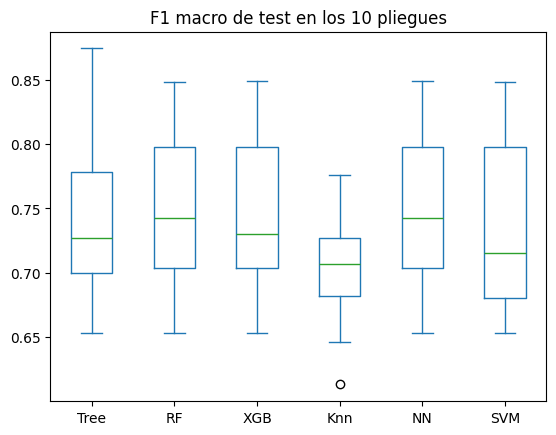

In [84]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')
plt.title('F1 macro de test en los 10 pliegues')
plt.show()

In [85]:
#Train vs Test para revisar overfitting (más de 5 puntos de diferencia es overfitting)
resumen = pd.DataFrame({'F1 train': comparacion_train.mean(), 'F1 test': comparacion_CV.mean(),
                        'Desviación test': comparacion_CV.std()})
resumen['Diferencia'] = resumen['F1 train'] - resumen['F1 test']
resumen.round(3)

,F1 train,F1 test,Desviación test,Diferencia
Tree,0.747,0.746,0.073,0.001
RF,0.755,0.751,0.062,0.004
XGB,0.755,0.749,0.069,0.006
Knn,0.716,0.701,0.047,0.015
NN,0.755,0.754,0.066,0.001
SVM,0.755,0.738,0.070,0.017


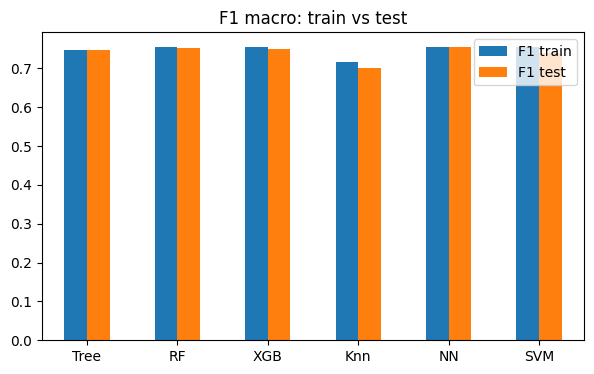

In [86]:
resumen[['F1 train','F1 test']].plot(kind='bar', figsize=(7,4))
plt.title('F1 macro: train vs test')
plt.xticks(rotation=0)
plt.show()

La diferencia entre train y test es menor a 0.02 en todos los modelos, así que ninguno tiene overfitting, y los seis quedan entre 0.70 y 0.75 de F1 macro. Ahora vemos cómo se equivoca cada uno.

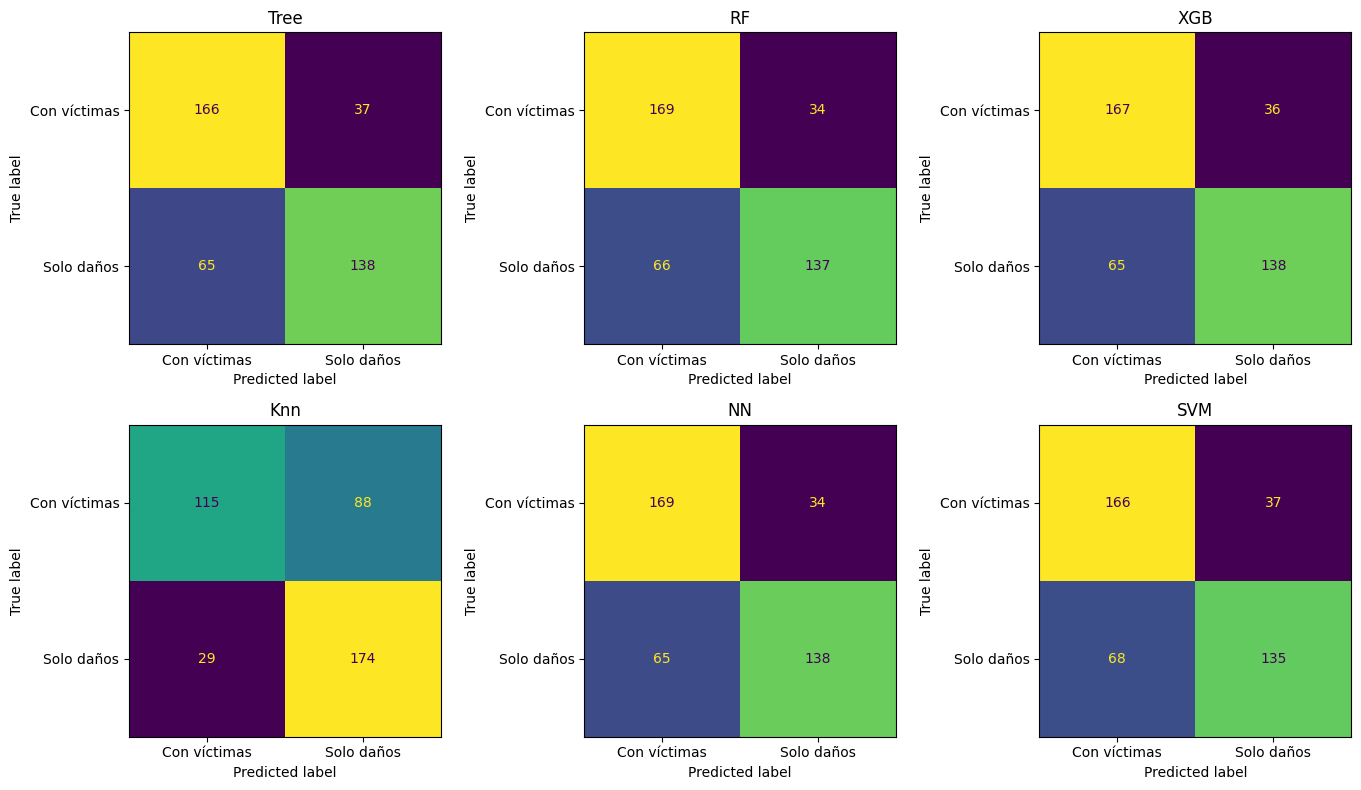

In [87]:
#Matrices de confusión de los 6 modelos (cada accidente se predice con un modelo que no lo vio)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

modelos = {'Tree':modelTree, 'RF':model_rf, 'XGB':model_xgb, 'Knn':model_knn, 'NN':model_rn, 'SVM':model_svm}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (nombre, modelo) in zip(axes.ravel(), modelos.items()):
    prediccion = cross_val_predict(modelo, X, Y, cv=cv)
    ConfusionMatrixDisplay.from_predictions(Y, prediccion, display_labels=labelencoder.classes_, ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

Tree AUC = 0.797
RF AUC = 0.803
XGB AUC = 0.798
Knn AUC = 0.739
NN AUC = 0.809
SVM AUC = 0.76


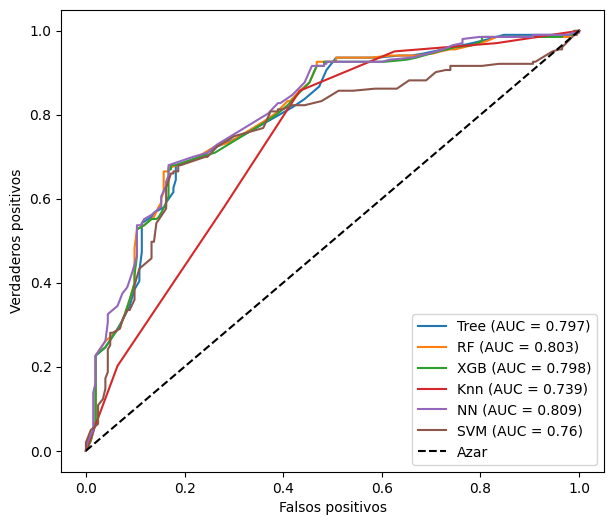

In [88]:
#Curvas ROC de los 6 modelos
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))
for nombre, modelo in modelos.items():
    if nombre == 'SVM':
        puntaje = cross_val_predict(modelo, X, Y, cv=cv, method='decision_function')
    else:
        puntaje = cross_val_predict(modelo, X, Y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(Y, puntaje)
    print(nombre, 'AUC =', round(auc(fpr, tpr), 3))
    plt.plot(fpr, tpr, label=nombre + ' (AUC = ' + str(round(auc(fpr, tpr), 3)) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.legend()
plt.show()

In [89]:
#Medidas de cada modelo con las predicciones de la validación cruzada
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

filas = []
for nombre, modelo in modelos.items():
    prediccion = cross_val_predict(modelo, X, Y, cv=cv)
    filas.append({'Modelo': nombre,
                  'Exactitud': accuracy_score(Y, prediccion),
                  'Precisión (Con víctimas)': precision_score(Y, prediccion, pos_label=0),
                  'Recall (Con víctimas)': recall_score(Y, prediccion, pos_label=0),
                  'Recall (Solo daños)': recall_score(Y, prediccion, pos_label=1),
                  'F1 macro': f1_score(Y, prediccion, average='macro')})
pd.DataFrame(filas).set_index('Modelo').round(3)

,Exactitud,Precisión (Con víctimas),Recall (Con víctimas),Recall (Solo daños),F1 macro
Modelo,,,,,
Tree,0.749,0.719,0.818,0.680,0.748
RF,0.754,0.719,0.833,0.675,0.752
XGB,0.751,0.720,0.823,0.680,0.750
Knn,0.712,0.799,0.567,0.857,0.706
NN,0.756,0.722,0.833,0.680,0.755
SVM,0.741,0.709,0.818,0.665,0.740


Conclusiones sobre la calidad de los modelos:

Los seis modelos quedaron entre 0.70 y 0.75 de F1 macro en test. La red neuronal (0.754), el Random Forest (0.751), XGBoost (0.749) y el árbol (0.746) están prácticamente empatados, porque la diferencia entre ellos (menos de un punto) es mucho menor que la variación entre pliegues (entre 0.05 y 0.07). El SVM queda un poco más abajo (0.738) y KNN es el peor (0.701).

No hay overfitting en ninguno (diferencias entre 0.001 y 0.017) ni se ve un underfitting grave, pero el techo de ~0.75 viene de los datos: solo hay tres variables y varias combinaciones se repiten en accidentes de las dos clases. Las matrices de confusión lo muestran. Tree, Random Forest, XGBoost, red neuronal y SVM se parecen mucho: detectan cerca del 82-83 % de los accidentes con víctimas pero solo el 67-68 % de los de solo daños, es decir, tienden a marcar de más como "con víctimas". KNN hace lo contrario: acierta el 86 % de los de solo daños pero solo el 57 % de los de con víctimas, y por eso es el menos conveniente si lo que importa es no pasar por alto los accidentes graves. En las curvas ROC la red neuronal (AUC 0.809) y el Random Forest (0.803) quedan arriba, XGBoost (0.798) y el árbol (0.797) un poco más abajo, y el SVM (0.760) y KNN (0.739) son los que menos separan las dos clases; todos están por encima del azar.

En general la calidad es moderada: el modelo acierta tres de cada cuatro accidentes. Sirve para ver qué condiciones se asocian con accidentes graves, pero no para decidir casos individuales; seguramente la gravedad depende de cosas que la base no registra (velocidad, uso de casco, tipo de choque).

# 13. Hiperparametrización con GridSearchCV

Probamos varias combinaciones de hiperparámetros de cada modelo con `GridSearchCV`, con el mismo `cv` de 10 pliegues y el F1 macro como medida. Con `refit=True` queda entrenado el mejor modelo de cada búsqueda. Para cada uno revisamos el overfitting comparando el F1 de train y de test de la mejor combinación, y guardamos el F1 en la tabla `medidas`.

Aunque basta con ajustar el mejor modelo, ajustamos los seis para elegir el definitivo en igualdad de condiciones. Igual que en la validación cruzada, KNN, red neuronal y SVM usan las variables numéricas normalizadas.

In [90]:
#Configuración hiperparametrización
from sklearn.model_selection import GridSearchCV
scoring='f1_macro'
#cv es el mismo StratifiedKFold de 10 pliegues de la validación cruzada

In [91]:
#Configuración de datos
X = data.drop(objetivo, axis = 1) # Variables predictoras
Y = data[objetivo] #Variable objetivo

In [92]:
#Medida de evaluación del mejor modelo
medidas= pd.DataFrame(index=['f1 de la CV'])

# **Hiperparametrización Árbol de Clasificación**

In [93]:
#  Arbol
from sklearn.tree import DecisionTreeClassifier
modelTree = DecisionTreeClassifier(random_state=42)

# Definir los hiperparametros
criterion=['entropy','gini'] #Indice de información
min_samples_leaf=[2,5,10,20,50] # Cantidad de registros por hoja
max_depth=[None,2,3,5,10] #Niveles de profundidad

In [94]:
#Hiperparametrización
param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelTree= grid.best_estimator_

# Mejores párametros
print( grid.best_params_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}


In [95]:
#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

Train CV: 0.747338916201283
Test CV: 0.7464927237079176


In [96]:
#Comparación de medidas
medidas['Tree']=grid.best_score_
medidas

,Tree
f1 de la CV,0.746493


Mejor árbol: criterio entropy, sin límite de profundidad y 10 registros por hoja. F1 de 0.746 en test y 0.747 en train, igual que con la configuración inicial.

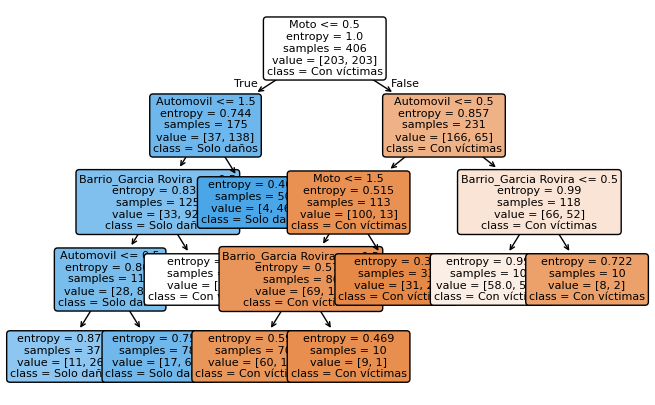

In [97]:
#Mejor modelo
from sklearn.tree import plot_tree
plt.figure(figsize=(8,5))
plot_tree(modelTree, feature_names=X.columns.values, class_names=labelencoder.classes_, rounded=True, filled=True, fontsize=8)
plt.show()

# **Hiperparametrización Random Forest para Clasificación**

In [98]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(random_state=42)

# Definir los hiperparametros
n_estimators=[50,100,200]        # Cantidad de árboles
criterion=['entropy','gini']      # Indice de información
min_samples_leaf=[2,10,50]    # Cantidad de registros por hoja
max_depth=[None,5,10]         # Niveles de profundidad

In [99]:
#Hiperparametrización
param_grid = dict(n_estimators=n_estimators, criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
grid = GridSearchCV(estimator=modelRF, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelRF = grid.best_estimator_

# Mejores parámetros
print(grid.best_params_)

#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

#Medida de evaluación del mejor modelo
medidas['RF']=grid.best_score_
medidas

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
Train CV: 0.754715089776175
Test CV: 0.7537956809129556


,Tree,RF
f1 de la CV,0.746493,0.753796


Mejor Random Forest: 200 árboles, criterio entropy, sin límite de profundidad y 10 registros por hoja. Sube de 0.751 a 0.754 en test, con 0.755 en train. En la gráfica, `Moto` es la variable más importante.

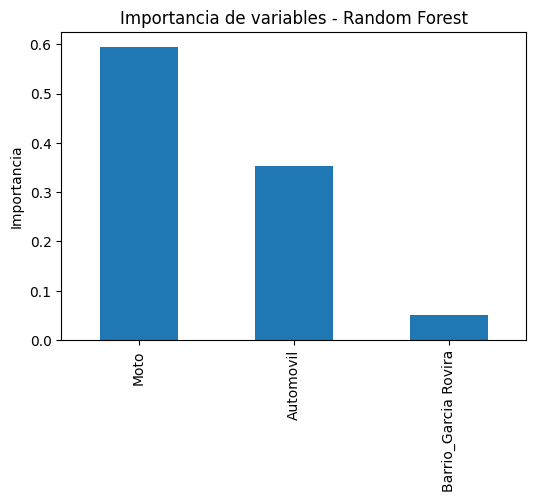

In [100]:
#Importancia de variables del mejor bosque
importancias = pd.Series(modelRF.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
importancias.plot(kind='bar')
plt.title("Importancia de variables - Random Forest")
plt.ylabel("Importancia")
plt.show()

# **Hiperparametrización XGBoost**

In [101]:
#XGBoost
from xgboost import XGBClassifier
modelXGB = XGBClassifier(random_state=42)

# Definir los hiperparametros
n_estimators=[50,100,200]       # Cantidad de árboles
max_depth=[2,3,5]               # Niveles de profundidad
learning_rate=[0.03,0.1,0.3]    # Tasa de aprendizaje

In [102]:
#Hiperparametrización
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate)
grid = GridSearchCV(estimator=modelXGB, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelXGB = grid.best_estimator_

# Mejores parámetros
print(grid.best_params_)

#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

#Medida de evaluación del mejor modelo
medidas['XGB']=grid.best_score_
medidas

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Train CV: 0.7547985015421658
Test CV: 0.7488493085920422


,Tree,RF,XGB
f1 de la CV,0.746493,0.753796,0.748849


La mejor combinación (100 árboles, profundidad 3 y tasa de aprendizaje 0.1) es la misma que ya teníamos, así que se queda en 0.749 en test (0.755 en train).

# **Hiperparametrización Knn para Clasificación**

In [103]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(data[predictoras_numericas]) #Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas])
X.head()

,Moto,Automovil,Barrio_Garcia Rovira
19647,0.000000,0.333333,1
19661,0.333333,0.333333,0
19668,0.333333,0.333333,1
19670,0.333333,0.000000,0
19678,0.333333,0.000000,0


In [104]:
#KNN
from sklearn.neighbors  import KNeighborsClassifier
modelKnn = KNeighborsClassifier()

# Definir los hiperparametros
n_neighbors=[1,3,5,7,13,27]
metric=['euclidean','manhattan']

#Grid
param_grid = dict(n_neighbors=n_neighbors, metric=metric)
grid = GridSearchCV(estimator=modelKnn, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelKnn= grid.best_estimator_

# Mejores párametros
print( grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 13}


In [105]:
#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


#Medida de evaluación del mejor modelo
medidas['Knn']=grid.best_score_
medidas

Train CV: 0.7208786220968041
Test CV: 0.7184072291535832


,Tree,RF,XGB,Knn
f1 de la CV,0.746493,0.753796,0.748849,0.718407


Mejor KNN: 13 vecinos con distancia euclidiana. Mejora de 0.701 a 0.718 en test, pero sigue siendo el más bajo.

# **Hiperparametrización Red Neuronal**

In [106]:
#Red Neuronal

from sklearn.neural_network import MLPClassifier
modelNN = MLPClassifier()


# Definir los parametros
random_state=[3] #Semilla para generar número pseudoaleatorios
solver=['adam'] # Regla de aprendizaje ['adam','sgd','lbfgs']
learning_rate_init=[0.001, 0.01, 0.1] #valor tasa de aprendizaje
activation=['logistic', 'relu'] #'identity’, ‘logistic’, ‘tanh’, ‘relu’
hidden_layer_sizes=[5,10,20,[8, 4]] # neuronas de la capa oculta (input+output/2)
max_iter = [500] #iteraciones

#Grid
param_grid = dict(random_state=random_state,solver=solver,activation=activation, hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter,
                  learning_rate_init=learning_rate_init)
grid = GridSearchCV(estimator=modelNN, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelNN= grid.best_estimator_

# Mejores párametros
print( grid.best_params_)

{'activation': 'logistic', 'hidden_layer_sizes': 5, 'learning_rate_init': 0.01, 'max_iter': 500, 'random_state': 3, 'solver': 'adam'}


In [107]:
#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


#Medida de evaluación del mejor modelo
medidas['NN']=grid.best_score_
medidas

Train CV: 0.754715089776175
Test CV: 0.7537956809129556


,Tree,RF,XGB,Knn,NN
f1 de la CV,0.746493,0.753796,0.748849,0.718407,0.753796


Mejor red neuronal: activación logística, 5 neuronas en la capa oculta y tasa de aprendizaje de 0.01. Queda en 0.754 en test (0.755 en train), igual que antes.

# **Hiperparametrización SVM para Clasificación**

In [108]:
#SVM
from sklearn.svm import SVC
modelSVM = SVC()

# Definir los hiperparametros
C=[0.1,1,10] #Margen blando 1
kernel=['linear', 'rbf','poly'] #'linear', 'poly', 'rbf', 'sigmoid'
gamma=['scale','auto',0.01]

#Grid
param_grid = dict(C=C, kernel=kernel,gamma=gamma)
grid = GridSearchCV(estimator=modelSVM, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
grid.fit(X, Y)

#Mejor modelo
modelSVM= grid.best_estimator_

# Mejores párametros
print( grid.best_params_)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [109]:
#Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


#Medida de evaluación del mejor modelo
medidas['SVM']=grid.best_score_
medidas

Train CV: 0.7511518496055458
Test CV: 0.7505967955630287


,Tree,RF,XGB,Knn,NN,SVM
f1 de la CV,0.746493,0.753796,0.748849,0.718407,0.753796,0.750597


Mejor SVM: kernel rbf, C = 0.1 y gamma scale. Sube de 0.738 a 0.751 en test, con 0.751 en train.

# Selección del mejor modelo

Después de ajustar los hiperparámetros el F1 queda entre 0.718 y 0.754. La red neuronal y el Random Forest empatan en el primer lugar (0.754), seguidos por el SVM (0.751), XGBoost (0.749), el árbol (0.746) y KNN (0.718). El ajuste mejoró poco: la red neuronal, XGBoost y el árbol quedaron igual, el Random Forest subió de 0.751 a 0.754, el SVM de 0.738 a 0.751 y KNN de 0.701 a 0.718. En todos la diferencia entre train y test sigue siendo mínima, así que no hay overfitting. Con tres variables, los hiperparámetros casi no cambian nada.

Entre la red neuronal y el Random Forest elegimos el Random Forest: tiene el mismo F1, no necesita normalizar las variables (más simple para el despliegue) y además nos entrega la importancia de las variables.

In [110]:
medidas

,Tree,RF,XGB,Knn,NN,SVM
f1 de la CV,0.746493,0.753796,0.748849,0.718407,0.753796,0.750597


In [111]:
#Modelo seleccionado
modelo_final=modelRF

# 14. Modelo final y guardado

Como elegimos el Random Forest, que no necesita normalización, devolvemos las variables numéricas a su escala original y entrenamos el modelo final con todos los datos. Después lo evaluamos con predicciones de la validación cruzada (cada accidente lo predice un modelo que no lo vio) y lo guardamos en un `.pkl` junto con el LabelEncoder y la información que necesita el notebook de despliegue.

In [112]:
# Si selecciona Tree, RandomForest o XGBoost se desnormaliza con la siguiente instrucción
#Si selecciona Knn, NN, SVM -> No se desnormaliza y se comenta la siguiente instrucción

X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [113]:
#Modelo final con todos los datos
modelo_final.fit(X, Y)

RandomForestClassifier(criterion='entropy', min_samples_leaf=10,
                       n_estimators=200, random_state=42)

Exactitud: 0.756
              precision    recall  f1-score   support

Con víctimas       0.72      0.83      0.77       203
  Solo daños       0.80      0.68      0.74       203

    accuracy                           0.76       406
   macro avg       0.76      0.76      0.75       406
weighted avg       0.76      0.76      0.75       406



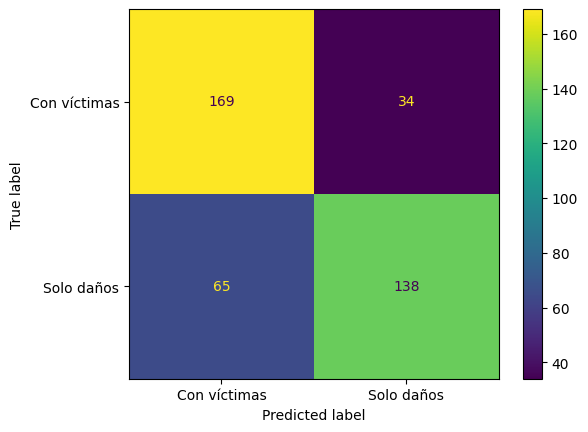

In [114]:
#Evaluación del modelo final (cada accidente se predice con un modelo que no lo vio)
from sklearn import metrics

Y_pred = cross_val_predict(modelo_final, X, Y, cv=cv)

print("Exactitud:", round(metrics.accuracy_score(Y, Y_pred), 3))
print(metrics.classification_report(Y, Y_pred, target_names=labelencoder.classes_))

cm = metrics.confusion_matrix(Y, Y_pred)
ConfusionMatrixDisplay(cm, display_labels=labelencoder.classes_).plot()
plt.show()

Con las predicciones de la validación cruzada la exactitud del Random Forest final es 0.756. Detecta bien los accidentes con víctimas (recall de 0.83, precisión de 0.72), pero en los de solo daños el recall baja a 0.68 (precisión de 0.80): de cada 3 accidentes que solo dejaron daños, casi 1 lo marca como "con víctimas". Es un sesgo que puede servir si lo más importante es no pasar por alto un accidente grave, a cambio de más falsas alarmas. Como los hiperparámetros se eligieron con estos mismos pliegues, las cifras pueden ser un poco optimistas.

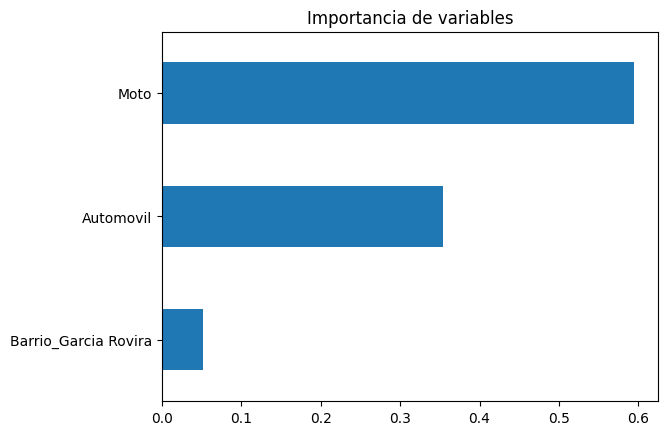

In [115]:
#Importancia de variables (si el modelo la entrega)
if hasattr(modelo_final, 'feature_importances_'):
    pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
    plt.title('Importancia de variables')
    plt.show()
else:
    print("Este modelo no entrega importancia de variables")

In [116]:
#Se guarda el modelo
import pickle

info_despliegue['nombre_modelo'] = 'Random Forest'
info_despliegue['usa_escalado'] = False   #True si el modelo se entrenó con las variables numéricas normalizadas
info_despliegue['clases'] = labelencoder.classes_.tolist()
info_despliegue['metricas_cv'] = {'f1_macro': round(float(medidas['RF'].iloc[0]), 3),
                                  'accuracy': round(float(metrics.accuracy_score(Y, Y_pred)), 3)}

filename = 'modelo-class-accidentes.pkl'
variables = X.columns._values
pickle.dump({'modelo': modelo_final, 'labelencoder': labelencoder, 'variables': list(variables),
             'scaler': min_max_scaler, 'info': info_despliegue}, open(filename, 'wb'))

# Conclusión general del proyecto

Trabajamos con 406 accidentes de la Comuna Centro de Bucaramanga en 2017. Los datos estaban completos (sin nulos, duplicados ni errores) y, al juntar heridos con muertos, las dos clases quedaron balanceadas (203 cada una).

De las 8 variables candidatas, las que se relacionan con la gravedad son el número de motos, el número de automóviles y el barrio: más motos se asocia con accidentes con víctimas y más automóviles con accidentes de solo daños.

Los seis modelos quedaron entre 0.70 y 0.75 de F1 macro, sin overfitting, y varios empatan. Después de ajustar los hiperparámetros elegimos el Random Forest (F1 de 0.754 en la validación cruzada). Con solo tres variables el desempeño tiene un techo, y el modelo tiende a clasificar de más como "con víctimas".

Limitaciones: son pocos datos (una comuna y un año), pocas variables, y dejamos fuera columnas como peatones y camionetas. El modelo sirve para analizar qué condiciones se asocian con accidentes graves, no para decidir casos individuales.